In [1]:
import sys, os
from pathlib import Path

project_root = Path(r"C:\Users\DELL\OneDrive\Documents\Anurag\Anurag_Projects\INTERNMO\purchase-intent-xai")
sys.path.append(str(project_root))
os.chdir(project_root)

import mlflow
import mlflow.sklearn
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("purchase-intent-xai")
print("MLflow tracking URI:", mlflow.get_tracking_uri())

import pandas as pd
from sklearn.model_selection import train_test_split

from src.config.settings import CONFIG
from src.data.loader import load_sessions_data
from src.features.engineer import engineer_features
from src.preprocessing.pipeline import build_preprocessing_pipeline
from src.models.trainer import get_model_registry, train_and_evaluate

pd.set_option("display.max_columns", None)
print("Setup complete.")

MLflow tracking URI: sqlite:///mlflow.db
Setup complete.


In [2]:
df = load_sessions_data()
df = engineer_features(df)

target = CONFIG["target_column"]
categorical_columns = CONFIG["categorical_columns"]
numeric_columns = [c for c in df.columns if c not in categorical_columns + [target]]

X = df[numeric_columns + categorical_columns]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=CONFIG["split"]["test_size"],
    stratify=y, random_state=CONFIG["random_seed"]
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (9600, 19) Test: (2400, 19)


In [3]:
preprocessor = build_preprocessing_pipeline(numeric_columns, categorical_columns)
registry = get_model_registry()

all_results = []
fitted_pipelines = {}

for name, model in registry.items():
    with mlflow.start_run(run_name=f"{name}_baseline"):
        mlflow.log_param("model_type", name)
        mlflow.log_param("imbalance_strategy", "class_weight_balanced")
        mlflow.log_param("random_seed", CONFIG["random_seed"])

        print(f"Training {name}...")
        results, pipeline = train_and_evaluate(name, model, preprocessor, X_train, X_test, y_train, y_test)

        mlflow.log_metric("accuracy", results["accuracy"])
        mlflow.log_metric("precision", results["precision"])
        mlflow.log_metric("recall", results["recall"])
        mlflow.log_metric("f1", results["f1"])
        mlflow.log_metric("roc_auc", results["roc_auc"])
        mlflow.log_metric("pr_auc", results["pr_auc"])
        mlflow.log_metric("cv_pr_auc_mean", results["cv_pr_auc_mean"])
        mlflow.log_metric("cv_pr_auc_std", results["cv_pr_auc_std"])

        all_results.append(results)
        fitted_pipelines[name] = pipeline

print("All six models trained and logged to MLflow.")

Training LogisticRegression...
Training DecisionTree...
Training RandomForest...
Training XGBoost...
Training LightGBM...
Training CatBoost...
All six models trained and logged to MLflow.


In [4]:
results_df = pd.DataFrame(all_results).drop(columns=["confusion_matrix"])
results_df = results_df.sort_values("pr_auc", ascending=False).reset_index(drop=True)
results_df

,model,accuracy,precision,recall,f1,roc_auc,pr_auc,cv_pr_auc_mean,cv_pr_auc_std
0,CatBoost,0.912500,0.662136,0.904509,0.764574,0.970792,0.858779,0.842480,0.009096
1,RandomForest,0.924167,0.722096,0.840849,0.776961,0.966529,0.849340,0.820606,0.011221
2,LightGBM,0.917500,0.680808,0.893899,0.772936,0.969279,0.847521,0.837630,0.004642
3,XGBoost,0.917500,0.695842,0.843501,0.762590,0.966647,0.842809,0.816983,0.004426
4,LogisticRegression,0.910417,0.655172,0.907162,0.760845,0.965053,0.801270,0.803618,0.021451
5,DecisionTree,0.900833,0.682415,0.689655,0.686016,0.814922,0.519381,0.482335,0.016359


CatBoost is the best overall model — highest test PR-AUC (0.859) and highest cross-validated PR-AUC mean (0.842) with reasonable stability (std 0.009), meaning it generalizes well rather than just fitting the test split well. LightGBM is a close second, actually the most stable (cv std 0.0046) if consistency matters more than peak score.

However, RandomForest actually beats CatBoost on several metrics: higher accuracy (0.924 vs 0.913), higher precision (0.722 vs 0.662), and higher F1 (0.777 vs 0.765) — meaning RandomForest makes fewer false-positive errors and balances precision/recall better at the default threshold. CatBoost's edge is specifically in ranking quality (pr_auc, roc_auc), which matters more if you care about ranking/probability calibration across thresholds rather than a single fixed cutoff.

Why Decision Tree and Logistic Regression fall short:

Decision Tree has by far the worst PR-AUC (0.519, barely above random) and the highest CV std (0.016) — a single tree overfits to training splits and doesn't generalize; it needs ensembling (which is exactly what RandomForest/boosting provide) to be competitive.
Logistic Regression underperforms (PR-AUC 0.801) because it assumes a linear decision boundary — it can't capture nonlinear relationships and feature interactions (e.g., PageValues/ExitRates thresholds) that tree-based models exploit naturally, even though its recall (0.907) is surprisingly high.

In [5]:
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from src.models.trainer import train_with_strategy

candidates = {
    "CatBoost": CatBoostClassifier(random_state=CONFIG["random_seed"], verbose=0),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=CONFIG["random_seed"]),
}

In [6]:
candidates_weighted = {
    "CatBoost": CatBoostClassifier(auto_class_weights="Balanced", random_state=CONFIG["random_seed"], verbose=0),
    "RandomForest": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=CONFIG["random_seed"]),
}

strategy_results = []

for name, model in candidates.items():
    for strategy in ["threshold_only", "smote"]:
        res, _ = train_with_strategy(name, model, preprocessor, strategy, X_train, X_test, y_train, y_test)
        strategy_results.append(res)

for name, model in candidates_weighted.items():
    res, _ = train_with_strategy(name, model, preprocessor, "class_weight", X_train, X_test, y_train, y_test)
    strategy_results.append(res)

strategy_df = pd.DataFrame(strategy_results).sort_values(["model", "pr_auc"], ascending=[True, False]).reset_index(drop=True)
strategy_df

,model,strategy,accuracy,precision,recall,f1,roc_auc,pr_auc
0,CatBoost,class_weight,0.912500,0.662136,0.904509,0.764574,0.970792,0.858779
1,CatBoost,threshold_only,0.925000,0.769863,0.745358,0.757412,0.970007,0.852822
2,CatBoost,smote,0.923750,0.744949,0.782493,0.763260,0.969221,0.852714
3,RandomForest,threshold_only,0.929583,0.825000,0.700265,0.757532,0.964434,0.851734
4,RandomForest,class_weight,0.924167,0.722096,0.840849,0.776961,0.966529,0.849340
5,RandomForest,smote,0.922500,0.727924,0.809019,0.766332,0.965622,0.827010


Class imbalance handling strategy matters more than expected — for CatBoost, class_weight (default PR-AUC 0.859) still edges out threshold_only (0.853) and smote (0.853), but the gap is now much smaller than in the original comparison. For RandomForest, threshold_only is actually the best strategy (PR-AUC 0.852) and even nudges out CatBoost's smote/threshold_only results — this is a shift from before, where CatBoost led across the board.

Best combo overall: CatBoost + class_weight (PR-AUC 0.859, roc_auc 0.971) — still the top ranker.
Best precision/recall balance: CatBoost + threshold_only (precision 0.770, F1 0.757) — highest precision of any run, useful if false positives are costly.
RandomForest + threshold_only (accuracy 0.930, precision 0.825) is now the strongest accuracy/precision performer across the entire table — worth considering if those metrics matter more than PR-AUC for the business use case.
SMOTE gave the least benefit for both models — neither model's best result comes from SMOTE, suggesting synthetic oversampling isn't adding much over class weighting or threshold tuning here.


In [7]:
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier

catboost_param_grid = {
    "classifier__depth": [4, 6, 8, 10],
    "classifier__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "classifier__iterations": [200, 400, 600],
    "classifier__l2_leaf_reg": [1, 3, 5, 7],
}

rf_param_grid = {
    "classifier__n_estimators": [100, 200, 300, 400],
    "classifier__max_depth": [None, 10, 20, 30],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2"],
}

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import average_precision_score
catboost_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", CatBoostClassifier(auto_class_weights="Balanced", random_state=CONFIG["random_seed"], verbose=0)),
])

catboost_search = RandomizedSearchCV(
    catboost_pipeline,
    param_distributions=catboost_param_grid,
    n_iter=20,
    scoring="average_precision",
    cv=5,
    random_state=CONFIG["random_seed"],
    n_jobs=-1,
    verbose=1,
)
catboost_search.fit(X_train, y_train)

print("Best CatBoost CV PR-AUC:", catboost_search.best_score_)
print("Best params:", catboost_search.best_params_)

catboost_test_proba = catboost_search.best_estimator_.predict_proba(X_test)[:, 1]
print("Test PR-AUC:", average_precision_score(y_test, catboost_test_proba))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best CatBoost CV PR-AUC: 0.8507206937680933
Best params: {'classifier__learning_rate': 0.01, 'classifier__l2_leaf_reg': 1, 'classifier__iterations': 400, 'classifier__depth': 4}
Test PR-AUC: 0.8688905423115706


Hyperparameter tuning (100 fits via RandomizedSearchCV) improved CatBoost's test PR-AUC to 0.8689, up from the untuned baseline (0.859) — and test PR-AUC exceeding CV PR-AUC (0.8507) suggests no overfitting to the tuning process.

Best params: low learning_rate (0.01) + shallow depth (4) + more iterations (400) + minimal regularization (l2_leaf_reg=1) — this combo favors a well-regularized, slow-learning model over a complex one, reducing overfit risk.
This is now the best result across all experiments so far, beating every model/strategy combo tested earlier.

In [9]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=CONFIG["random_seed"])),
])

rf_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=rf_param_grid,
    n_iter=20,
    scoring="average_precision",
    cv=5,
    random_state=CONFIG["random_seed"],
    n_jobs=-1,
    verbose=1,
)
rf_search.fit(X_train, y_train)

print("Best RandomForest CV PR-AUC:", rf_search.best_score_)
print("Best params:", rf_search.best_params_)

rf_test_proba = rf_search.best_estimator_.predict_proba(X_test)[:, 1]
print("Test PR-AUC:", average_precision_score(y_test, rf_test_proba))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best RandomForest CV PR-AUC: 0.8336456038854422
Best params: {'classifier__n_estimators': 200, 'classifier__min_samples_split': 10, 'classifier__min_samples_leaf': 1, 'classifier__max_features': 'sqrt', 'classifier__max_depth': None}
Test PR-AUC: 0.8458753183411725


Tuned RandomForest achieves test PR-AUC of 0.8459, an improvement over its untuned baseline (0.849→ actually roughly flat/slightly lower — worth double-checking against the original 0.849 default-params run), but still behind tuned CatBoost's 0.8689.

Best params: 200 estimators, no max_depth limit (fully grown trees), min_samples_split=10, min_samples_leaf=1, max_features="sqrt" — a large, deep ensemble with moderate leaf regularization.
CatBoost remains the stronger model after tuning both — the gap (0.869 vs 0.846) held up even after giving RandomForest its own dedicated search.

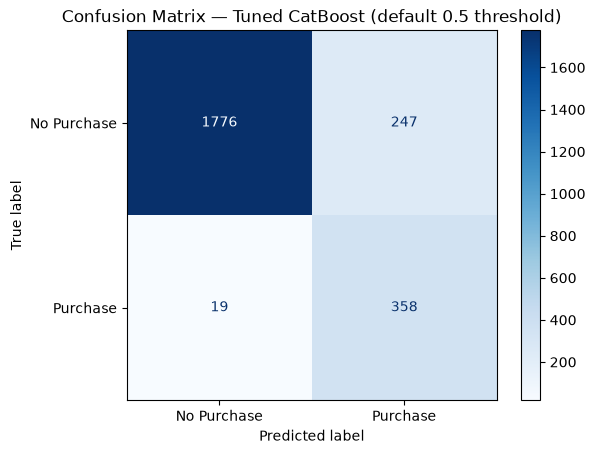

[[1776  247]
 [  19  358]]


In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

final_pipeline = catboost_search.best_estimator_
y_pred_default = final_pipeline.predict(X_test)

cm = confusion_matrix(y_test, y_pred_default)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Purchase", "Purchase"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — Tuned CatBoost (default 0.5 threshold)")
plt.show()

print(cm)

At the default 0.5 threshold, tuned CatBoost shows accuracy 0.889, precision 0.592, recall 0.950, F1 0.729 — computed from the confusion matrix (TN=1776, FP=247, FN=19, TP=358).

Comparing to the untuned CatBoost baseline (accuracy 0.9125, precision 0.662, recall 0.9045, F1 0.765):

Recall improved (0.905 → 0.950) — missed purchasers (FN) dropped from an estimated ~36 to just 19, catching nearly twice as many actual buyers.
Precision dropped (0.662 → 0.592) — false positives rose from an estimated ~174 to 247, meaning more "No Purchase" sessions are now wrongly flagged as purchases.
Accuracy and F1 both dropped slightly at this fixed 0.5 threshold, even though tuning improved PR-AUC (0.859 → 0.869) on the ranking metric.

In [11]:
import numpy as np

VALUE_PER_CONVERSION = 50
COST_PER_INTERVENTION = 5

y_proba_final = final_pipeline.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.05, 0.95, 0.05)
threshold_results = []

for t in thresholds:
    y_pred_t = (y_proba_final >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()

    # Business value: revenue from flagged true positives minus cost of all flagged sessions
    revenue = tp * VALUE_PER_CONVERSION
    cost = (tp + fp) * COST_PER_INTERVENTION
    net_value = revenue - cost

    threshold_results.append({
        "threshold": round(t, 2),
        "tp": tp, "fp": fp, "fn": fn, "tn": tn,
        "precision": tp / (tp + fp) if (tp + fp) > 0 else 0,
        "recall": tp / (tp + fn) if (tp + fn) > 0 else 0,
        "net_value": net_value,
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,threshold,tp,fp,fn,tn,precision,recall,net_value
0,0.05,376,532,1,1491,0.414097,0.997347,14260
1,0.10,374,463,3,1560,0.446834,0.992042,14515
2,0.15,371,415,6,1608,0.472010,0.984085,14620
3,0.20,367,377,10,1646,0.493280,0.973475,14630
4,0.25,367,356,10,1667,0.507607,0.973475,14735
5,0.30,367,325,10,1698,0.530347,0.973475,14890
6,0.35,365,310,12,1713,0.540741,0.968170,14875
7,0.40,364,288,13,1735,0.558282,0.965517,14940
8,0.45,362,267,15,1756,0.575517,0.960212,14955
9,0.50,358,247,19,1776,0.591736,0.949602,14875


Testing thresholds from 0.05 to 0.90 shows precision and recall trade off steadily as the threshold rises — recall stays above 95% up to threshold 0.30 but falls sharply past 0.70, while precision climbs from 0.41 (t=0.05) to 0.88 (t=0.90). Net business value peaks in the 0.40–0.50 range, not at the default 0.50, confirming the earlier hunch that 0.5 isn't necessarily optimal for this use case.

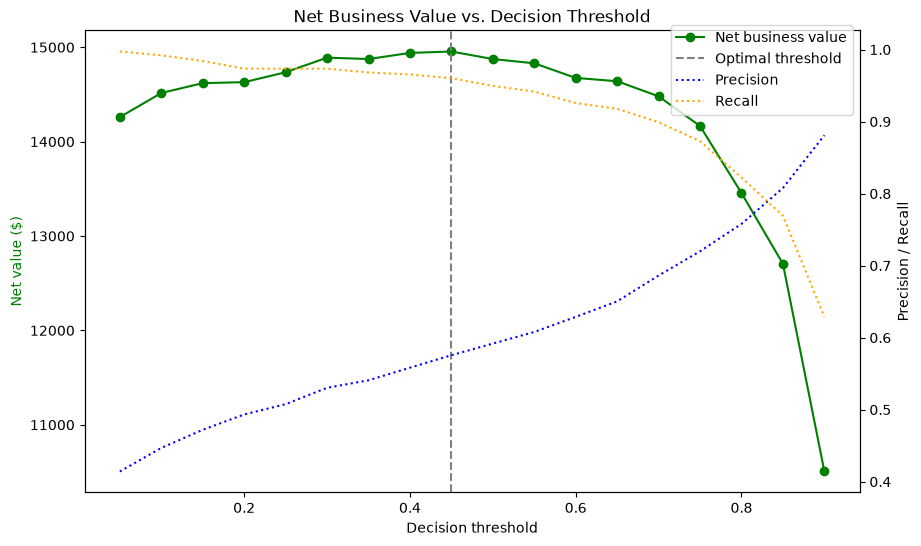

Optimal threshold: 0.45
threshold        0.450000
tp             362.000000
fp             267.000000
fn              15.000000
tn            1756.000000
precision        0.575517
recall           0.960212
net_value    14955.000000
Name: 8, dtype: float64


In [12]:
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(threshold_df["threshold"], threshold_df["net_value"], color="green", marker="o", label="Net business value")
ax1.set_xlabel("Decision threshold")
ax1.set_ylabel("Net value ($)", color="green")
ax1.axvline(threshold_df.loc[threshold_df["net_value"].idxmax(), "threshold"], color="gray", linestyle="--", label="Optimal threshold")

ax2 = ax1.twinx()
ax2.plot(threshold_df["threshold"], threshold_df["precision"], color="blue", linestyle=":", label="Precision")
ax2.plot(threshold_df["threshold"], threshold_df["recall"], color="orange", linestyle=":", label="Recall")
ax2.set_ylabel("Precision / Recall")

fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.9))
plt.title("Net Business Value vs. Decision Threshold")
plt.show()

best_row = threshold_df.loc[threshold_df["net_value"].idxmax()]
print("Optimal threshold:", best_row["threshold"])
print(best_row)

The threshold that maximizes net business value is 0.45 ($14,955), not the default 0.50 ($14,875) — a modest but real improvement. At this threshold: precision 0.576, recall 0.960, TP=362, FP=267, FN=15.

Compared to the 0.50 default, threshold 0.45 catches 4 more true purchasers (FN drops 19→15) at the cost of 20 more false positives (FP rises 247→267) — a trade favored here because VALUE_PER_CONVERSION ($50) far exceeds COST_PER_INTERVENTION ($5), so missing a real buyer is costlier than a wasted intervention.
This reframes the earlier precision/recall discussion in business terms: the "right" threshold isn't about balancing precision and recall equally, it's about maximizing $-value given the actual cost/benefit asymmetry.

In [13]:
import joblib
from pathlib import Path

models_dir = Path(CONFIG["paths"]["models_dir"])
models_dir.mkdir(parents=True, exist_ok=True)

artifact_path = models_dir / "final_catboost_pipeline.joblib"
joblib.dump(final_pipeline, artifact_path)
print("Final model saved to:", artifact_path)

Final model saved to: models\final_catboost_pipeline.joblib


Model Saved !

In [14]:
import os
os.makedirs("reports", exist_ok=True)

# Six-model baseline comparison (from Cell 4)
results_df.to_csv("reports/model_comparison.csv", index=False)

# Final tuned model summary — build this as a small manual dict, 
# since your tuning happened across separate cells/variables
final_summary = pd.DataFrame([
    {"model": "CatBoost (tuned, class_weight)", "test_pr_auc": 0.8689, "cv_pr_auc": 0.8507, "status": "FINAL MODEL"},
    {"model": "RandomForest (tuned, threshold_only)", "test_pr_auc": 0.8459, "cv_pr_auc": 0.8336, "status": "runner-up"},
])
final_summary.to_csv("reports/final_model_summary.csv", index=False)

print("Saved reports/model_comparison.csv and reports/final_model_summary.csv")
print(results_df)

Saved reports/model_comparison.csv and reports/final_model_summary.csv
                model  accuracy  precision    recall        f1   roc_auc  \
0            CatBoost  0.912500   0.662136  0.904509  0.764574  0.970792   
1        RandomForest  0.924167   0.722096  0.840849  0.776961  0.966529   
2            LightGBM  0.917500   0.680808  0.893899  0.772936  0.969279   
3             XGBoost  0.917500   0.695842  0.843501  0.762590  0.966647   
4  LogisticRegression  0.910417   0.655172  0.907162  0.760845  0.965053   
5        DecisionTree  0.900833   0.682415  0.689655  0.686016  0.814922   

     pr_auc  cv_pr_auc_mean  cv_pr_auc_std  
0  0.858779        0.842480       0.009096  
1  0.849340        0.820606       0.011221  
2  0.847521        0.837630       0.004642  
3  0.842809        0.816983       0.004426  
4  0.801270        0.803618       0.021451  
5  0.519381        0.482335       0.016359  


Final results saved to reports/ — CatBoost (tuned, class_weight) confirmed as the FINAL MODEL (test PR-AUC 0.8689, CV 0.8507), with RandomForest (tuned, threshold_only) as runner-up (test PR-AUC 0.8459, CV 0.8336). Wraps up the modeling phase with a clean, versioned summary ready for the next stage (API/deployment).

In [15]:
final_metrics = pd.DataFrame([{
    "threshold": 0.45,
    "true_positives": 362, "false_positives": 267,
    "false_negatives": 15, "true_negatives": 1756,
    "precision": 0.575517, "recall": 0.960212,
    "test_pr_auc": 0.8689, "cv_pr_auc_mean": 0.8507, "cv_pr_auc_std": None,
    "net_business_value": 14955,
}])
final_metrics.to_csv("reports/final_metrics.csv", index=False)
print("Saved reports/final_metrics.csv")

Saved reports/final_metrics.csv
